---
# Credit Risk Analysis - Data Mining Project
---

# Introduction

## Dataset
The **Credit Risk Dataset** ([Kaggle](https://www.kaggle.com/datasets/laotse/credit-risk-dataset)) contains **32,581 records** and **12 features** — a mix of numeric and categorical attributes including applicant age, income, loan amount, interest rate, loan grade, and default status.

## Motivation
Credit risk assessment is critical in finance — approving a bad loan causes financial loss, rejecting a good one means lost revenue. This project builds a data-driven pipeline using clustering, fuzzy inference, and genetic optimization to automate and explain loan screening decisions.

## Why This Dataset
- Real-world financial domain with direct business impact
- Mix of numeric and categorical features suitable for the full pipeline
- Large enough (32,581 rows) for statistically meaningful results
- Not a standard tutorial dataset (not Iris, Titanic, etc.)
- Contains `loan_status` for validating clustering and fuzzy outputs

----

## 1. Exploratory Data Analysis & Visualization

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv("credit_risk_dataset.csv")
print("Data Loaded Successfully!")
print(df.shape)
sns.set_theme(style="whitegrid")
df.head()

Data Loaded Successfully!
(32581, 12)


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


#### Interpretation
`loan_percent_income` and `loan_int_rate` are the most correlated with default (0.37 and 0.34). Higher interest rates and high loan-to-income ratios are the strongest indicators of default risk.

----

### Visualization 1: Distribution of Applicant Age

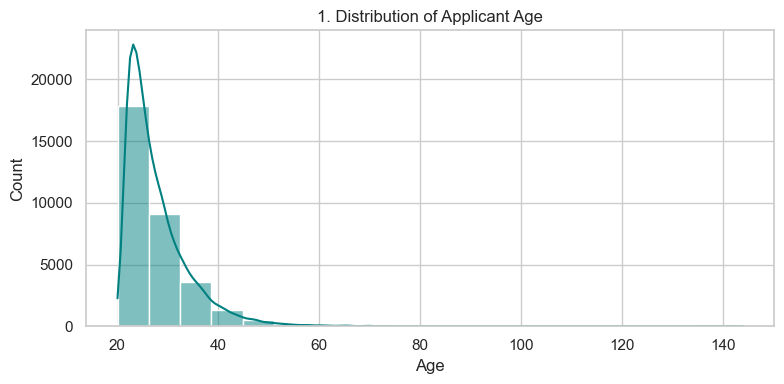

In [ ]:
plt.figure(figsize=(8,4))
sns.histplot(df['person_age'], bins=20, kde=True, color='teal')
plt.title('1. Distribution of Applicant Age')
plt.xlabel('Age')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

#### Interpretation
Most applicants are between 20 and 35. The distribution is right-skewed and contains clear outliers (e.g. age 144) that will be handled in preprocessing.

----

### Visualization 2: Loan Purposes

/var/folders/3y/lczwl1nn30d7n5239kjssq5w0000gn/T/ipykernel_23239/899262105.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='loan_intent', data=df, palette='viridis',


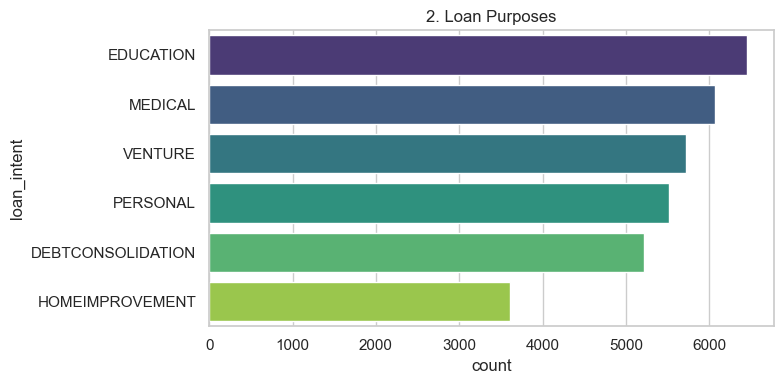

In [ ]:
plt.figure(figsize=(8,4))
sns.countplot(y='loan_intent', data=df, palette='viridis',
              order=df['loan_intent'].value_counts().index)
plt.title('2. Loan Purposes')
plt.tight_layout()
plt.show()

#### Interpretation
Education and medical are the most common loan purposes, suggesting many borrowers take loans out of necessity.

---

### Visualization 3: Correlation Matrix

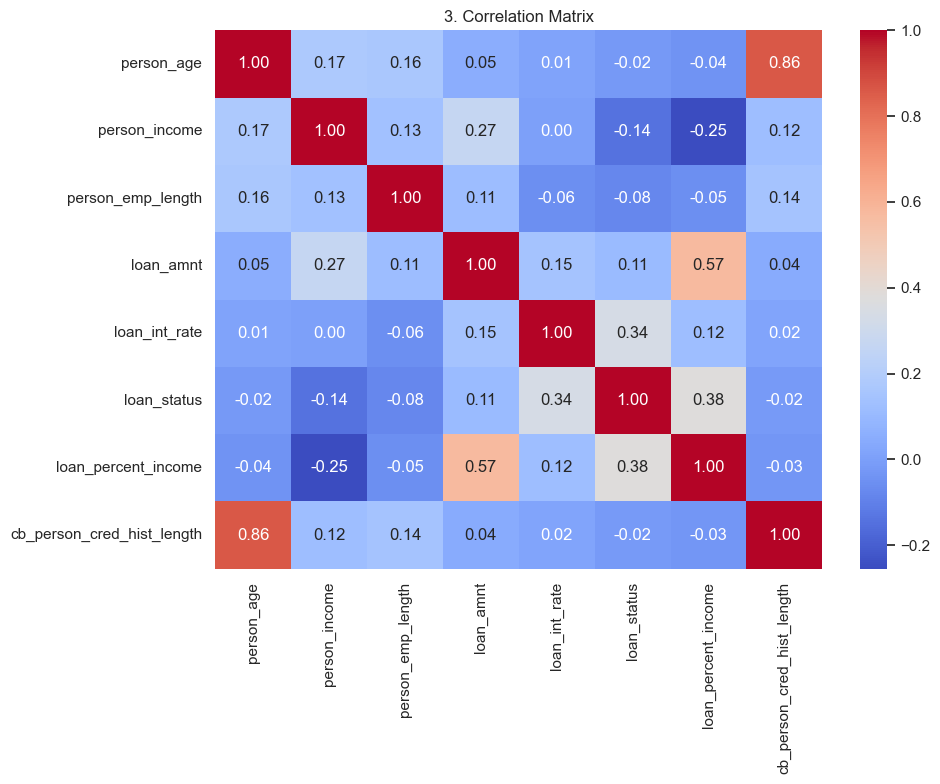

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('3. Correlation Matrix')
plt.tight_layout()
plt.show()

#### Interpretation
`loan_percent_income` and `loan_int_rate` have the strongest correlation with default (0.37 and 0.34). Higher interest rates and higher loan-to-income ratios increase default risk.

----

### Visualization 4: Loan Amount by Default Status

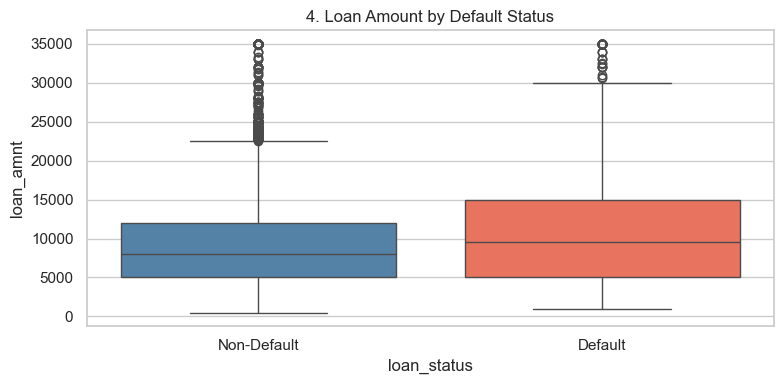

In [ ]:
plt.figure(figsize=(8,4))
sns.boxplot(x='loan_status', y='loan_amnt', data=df,
            hue='loan_status', palette={0:'steelblue', 1:'tomato'}, legend=False)
plt.xticks([0,1], ['Non-Default','Default'])
plt.title('4. Loan Amount by Default Status')
plt.tight_layout()
plt.show()

#### Interpretation
Defaulted loans have slightly higher amounts on average, but the overlap is large — meaning loan amount alone isn't a strong predictor of default.

----

### Visualization 5: Loan Grade vs Default Status

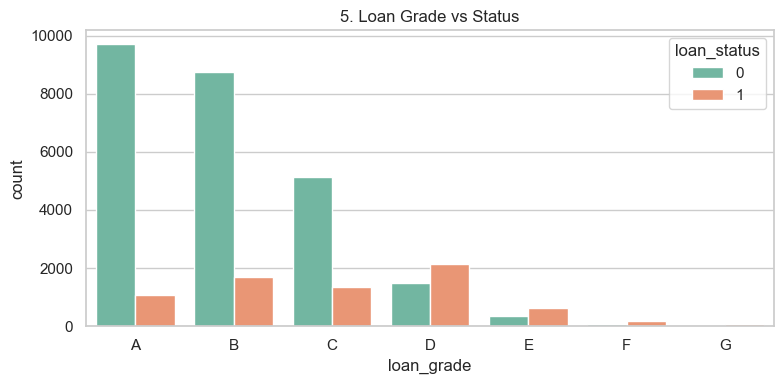

In [ ]:
plt.figure(figsize=(8,4))
sns.countplot(x='loan_grade', hue='loan_status', data=df, palette='Set2',
              order=['A','B','C','D','E','F','G'])
plt.title('5. Loan Grade vs Status')
plt.tight_layout()
plt.show()

#### Interpretation
Default rate clearly increases as grade drops from A to G, confirming that the lender's grading reflects actual risk well.

---

## 2. Data Preprocessing

Notes to keep in mind from EDA:
* Age is right skewd, using the log, or sqrt of it would be better (to make it more normal)

In [ ]:
df.isna().sum(), df.isna().sum().sum()

(person_age                       0
 person_income                    0
 person_home_ownership            0
 person_emp_length              895
 loan_intent                      0
 loan_grade                       0
 loan_amnt                        0
 loan_int_rate                 3116
 loan_status                      0
 loan_percent_income              0
 cb_person_default_on_file        0
 cb_person_cred_hist_length       0
 dtype: int64,
 4011)

That's actually not that a high number of null values compared to the number of data rows
and they're only in 2 columns so dealing with them isn't gonna be hard

Let's start with removing outliers because sometimes, the outlier rows also contain null values

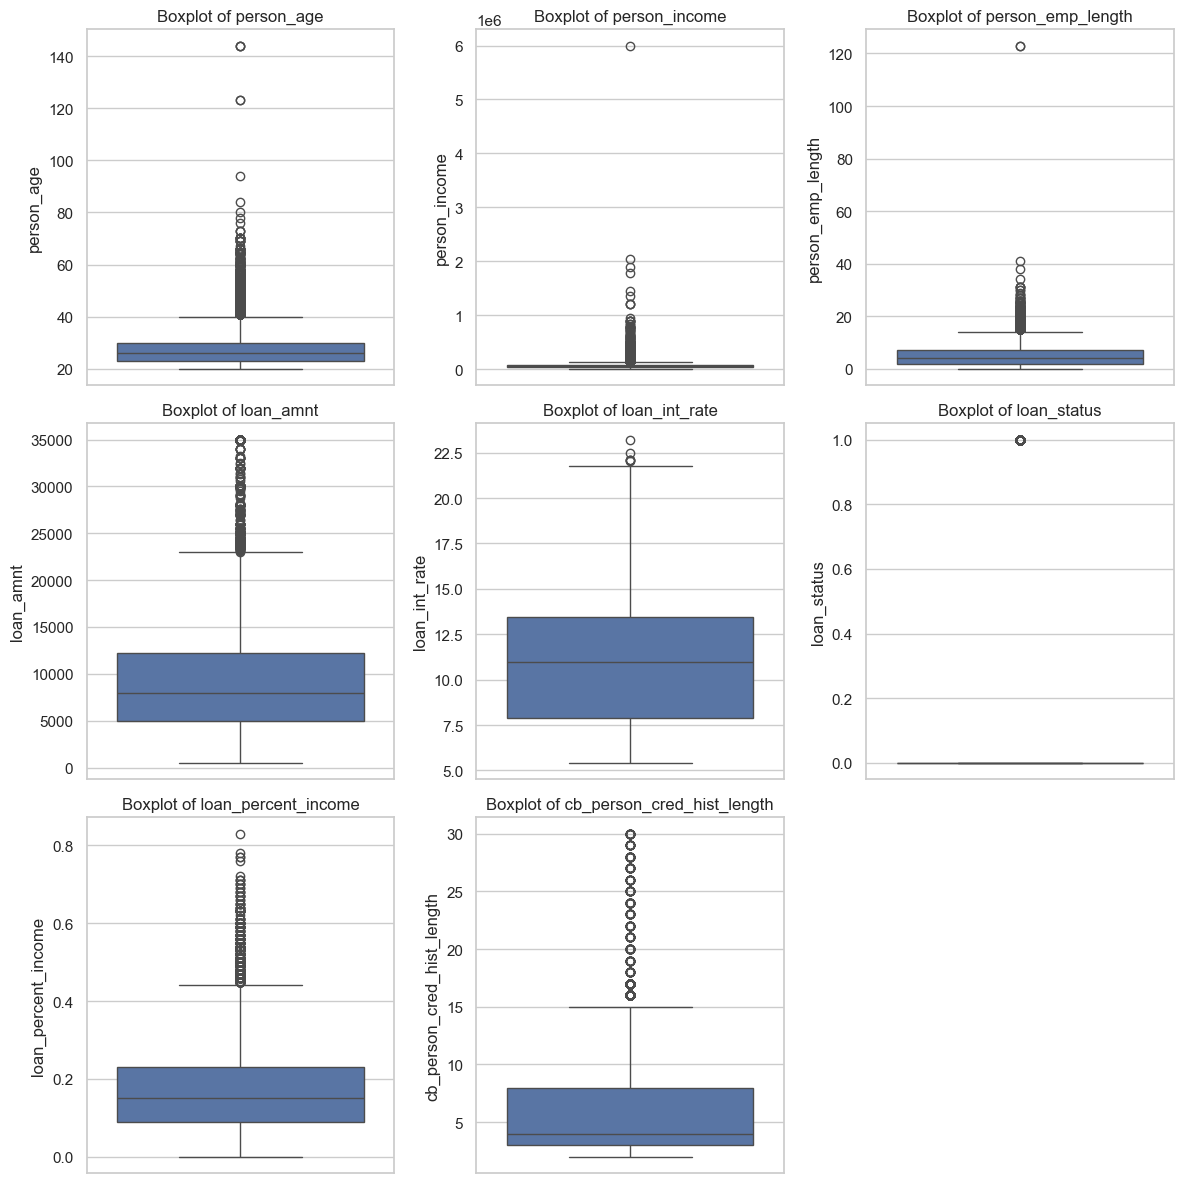

In [ ]:
import math
def plot_outliers_in_data(df):
    cols = df.select_dtypes(include=['number']).columns
    n_cols = 3
    n_rows = math.ceil(len(cols) / n_cols)

    plt.figure(figsize=(n_cols * 4, n_rows * 4))

    for i, column in enumerate(cols):
        plt.subplot(n_rows, n_cols, i + 1)
        sns.boxplot(y=df[column])
        plt.title(f'Boxplot of {column}')
        plt.tight_layout()


    plt.show()
plot_outliers_in_data(df)

In [ ]:
df.shape

(32581, 12)

we got alot of outliers, HOW FUN, let's remove them

In [ ]:
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

df = remove_outliers(df,'person_age')
df = remove_outliers(df,'person_income')
df = remove_outliers(df,'person_emp_length')
df = remove_outliers(df,'loan_amnt')
df = remove_outliers(df,'loan_percent_income')
df = remove_outliers(df,'cb_person_cred_hist_length')


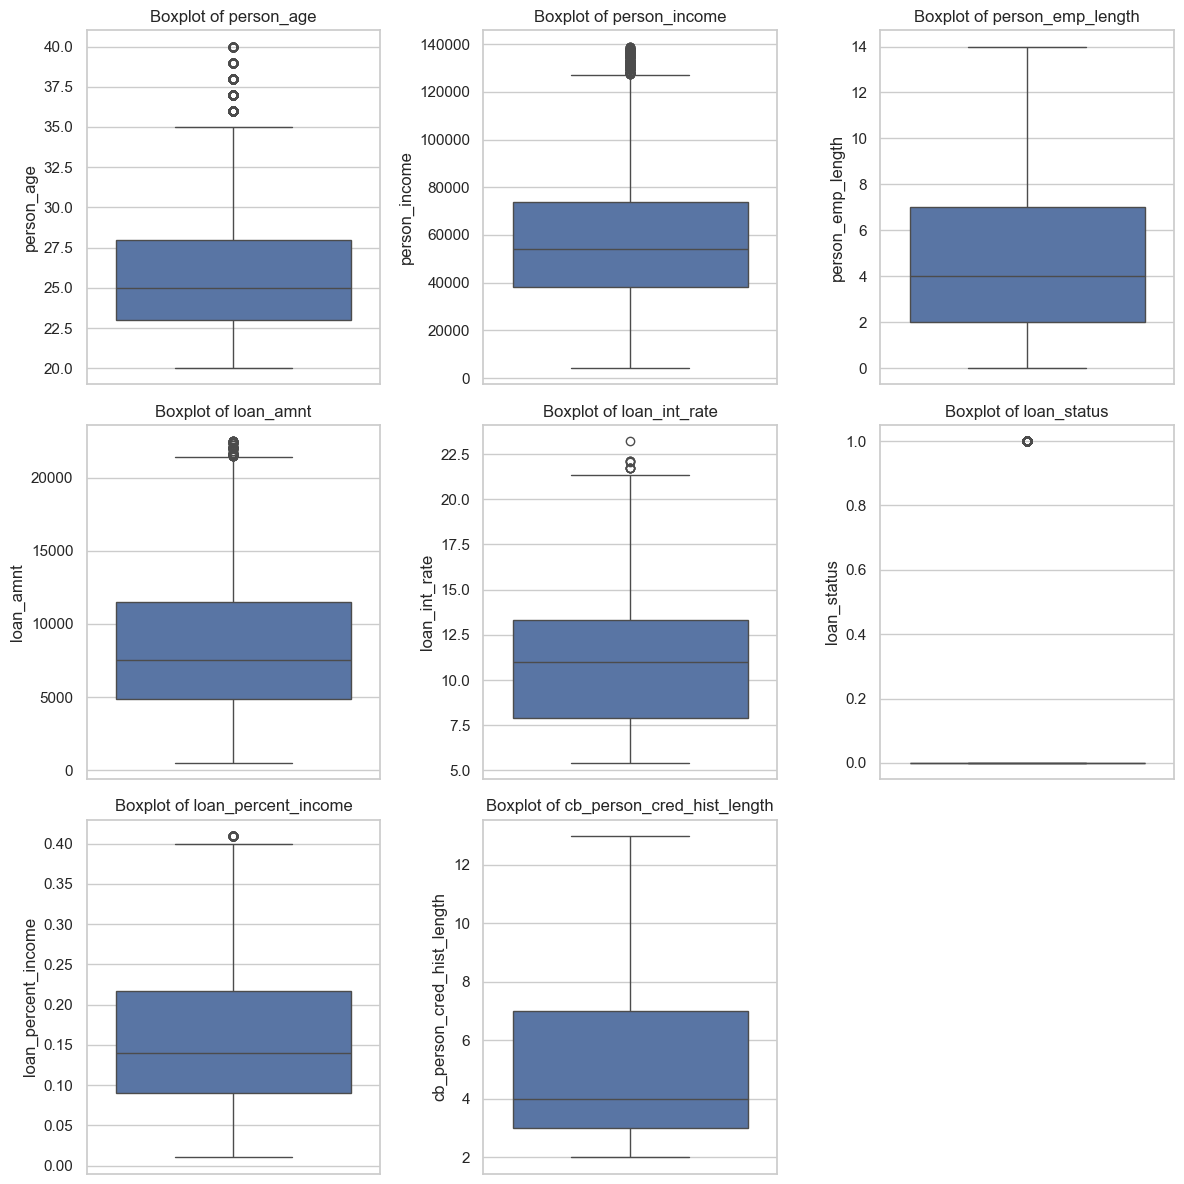

In [ ]:
plot_outliers_in_data(df)

In [ ]:
df.shape, (32581 - 25418)

((25418, 12), 7163)

would u look at how magical is that, we lost like, 7k row, but I hope it's for the best, now let's check nulls again

In [ ]:
df.isna().sum(), df.isna().sum().sum()

(person_age                       0
 person_income                    0
 person_home_ownership            0
 person_emp_length                0
 loan_intent                      0
 loan_grade                       0
 loan_amnt                        0
 loan_int_rate                 2413
 loan_status                      0
 loan_percent_income              0
 cb_person_default_on_file        0
 cb_person_cred_hist_length       0
 dtype: int64,
 2413)

I KNEW IT, we are now with 1 columns of nulls, which is hella easy to deal with and also less null values in that column

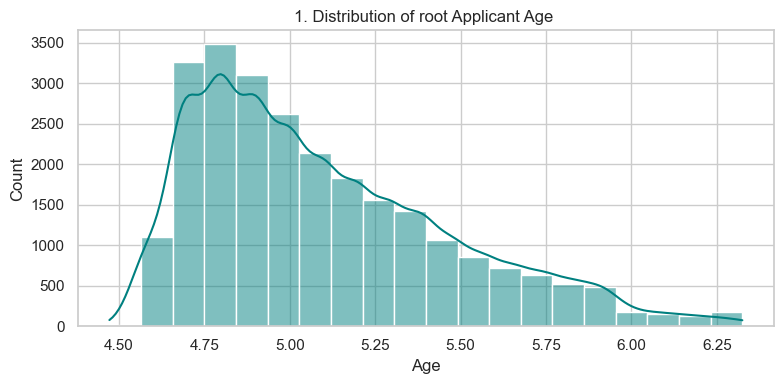

In [ ]:
plt.figure(figsize=(8,4))
sns.histplot(np.sqrt(df['person_age']), bins=20, kde=True, color='teal')
plt.title('1. Distribution of root Applicant Age ')
plt.xlabel('Age')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

I mean that does look better, so we will take the square root of age

In [ ]:
df.select_dtypes(include=['object']).columns


/var/folders/3y/lczwl1nn30d7n5239kjssq5w0000gn/T/ipykernel_23239/2318984544.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include=['object']).columns


Index(['person_home_ownership', 'loan_intent', 'loan_grade',
       'cb_person_default_on_file'],
      dtype='str')

it's safe to say that we can ONE-HOT encode all of the object values
except for loan_grade because it's actually ordinal so ordinal encoding is better for it

In [ ]:
df.select_dtypes(include=['number']).columns

Index(['person_age', 'person_income', 'person_emp_length', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_cred_hist_length'],
      dtype='str')

for numbers, let's go for StandardScaler, we are gonna fill loan_int_rate with median because we cant afford to drop more data

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder


def clean_fn(df, loan_int_rate_train_median):
    df["loan_int_rate"] = df["loan_int_rate"].fillna(loan_int_rate_train_median)
    df["person_age"] = np.sqrt(df["person_age"])
    return df


preprocessor = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(),
             ['person_age',"person_income","person_emp_length",
              "loan_amnt", "loan_int_rate","loan_percent_income",
              "cb_person_cred_hist_length"
                                       ,]),
            ('cat', OneHotEncoder(handle_unknown="ignore",sparse_output=False),
              ['person_home_ownership', 'loan_intent',"cb_person_default_on_file"]),
               ('cat2', OrdinalEncoder(handle_unknown="error"),
              ["loan_grade"])
        ])
preprocessor.set_output(transform="pandas")

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e

Now let's split and clean

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop('loan_status', axis=1)
y = df['loan_status']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train_transformed = preprocessor.fit_transform(clean_fn(X_train,X_train["loan_int_rate"].median()))

X_test_transformed = preprocessor.transform(clean_fn(X_test,X_train["loan_int_rate"].median()))

In [ ]:
X_train_transformed.head()

,num__person_age,num__person_income,num__person_emp_length,num__loan_amnt,num__loan_int_rate,num__loan_percent_income,num__cb_person_cred_hist_length,cat__person_home_ownership_MORTGAGE,cat__person_home_ownership_OTHER,cat__person_home_ownership_OWN,cat__person_home_ownership_RENT,cat__loan_intent_DEBTCONSOLIDATION,cat__loan_intent_EDUCATION,cat__loan_intent_HOMEIMPROVEMENT,cat__loan_intent_MEDICAL,cat__loan_intent_PERSONAL,cat__loan_intent_VENTURE,cat__cb_person_default_on_file_N,cat__cb_person_default_on_file_Y,cat2__loan_grade
12289,-0.818287,-0.679971,-1.288043,-0.415393,-0.867885,-0.002622,-0.675154,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
23308,0.246806,0.272284,1.960516,-0.085338,-0.193864,-0.448793,0.434137,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
8928,-0.275077,0.081833,1.369869,-0.601049,-0.072212,-0.783422,-1.044918,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0
5267,-0.543852,-0.299069,0.483898,-0.704191,-1.453133,-0.671879,-1.044918,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
1055,-0.818287,1.110269,-0.697396,1.977505,0.305898,0.555092,-1.044918,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0


In [ ]:
X_train_transformed.shape

(20334, 20)

And the data is cleaned and transformed

---

---
## 3. K-Medoid Clustering
---

In this section, K-Medoids clustering is applied to the preprocessed dataset in order to identify natural groupings among customers.

Unlike K-Means, K-Medoids selects actual data points as cluster centers (medoids), making it more robust to noise and outliers.

The optimal number of clusters is determined using:
- Elbow Method
- Silhouette Score

In [ ]:
#  !pip install scikit-learn-extra

In [ ]:
# !pip install numpy==1.26.4

In [ ]:
from sklearn.metrics import silhouette_score
from sklearn_extra.cluster import KMedoids

In [ ]:
X_cluster = X_train_transformed.copy()

Compute Elbow & Silhouette methods to estimate optimal k

In [ ]:
inertia = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    km = KMedoids(n_clusters=k, metric='manhattan', random_state=42)
    labels = km.fit_predict(X_cluster)

    inertia.append(km.inertia_)

    score = silhouette_score(X_cluster, labels, sample_size=2000, random_state=42)
    silhouette_scores.append(score)

Here we test different numbers of clusters (from 2 to 10) to see which one works best.

For each K:
- We run the K-Medoids model
- We calculate inertia (for the Elbow Method)
- We calculate the Silhouette Score to check how good the clustering is

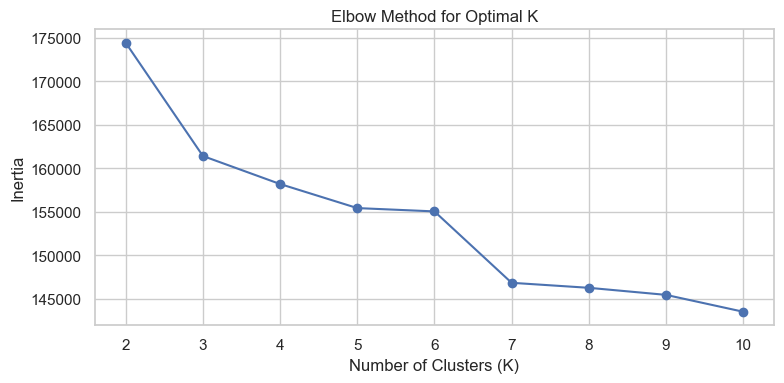

In [ ]:
plt.figure(figsize=(8,4))
plt.plot(K_range, inertia, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.tight_layout()
plt.show()

Elbow Method Analysis

The Elbow Method is used to decide the best number of clusters by looking at how inertia changes as K increases.

**What we notice from the plot:**
- There is a big drop in inertia from K=2 to K=3, which shows a strong improvement in clustering.
- After K=3, the decrease becomes slower and more gradual.
- From around K=7, the curve almost becomes flat, meaning adding more clusters does not help much.

**conclusion:**
K=3 seems like a good choice because after this point, the improvement in clustering quality becomes much smaller. However, the Elbow Method alone is not enough to make the final decision. That’s why we also need to check the Silhouette Score to better evaluate how well the clusters are separated before choosing the final K.

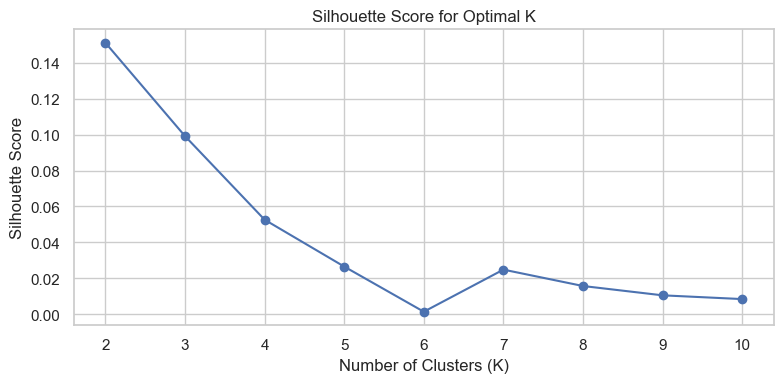

In [ ]:
plt.figure(figsize=(8,4))
plt.plot(K_range, silhouette_scores, marker='o')
plt.title('Silhouette Score for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.tight_layout()
plt.show()

The Silhouette Score shows how well each point fits inside its cluster compared to other clusters. Higher values mean better clustering.

**What we notice from the graph:**
- K=2 has the highest score (around 0.15), which is clearly better than the rest.
- After K=2, the score drops a lot at K=3.
- From K=4 onwards, the scores keep getting smaller and become very low.
- At K=6, the score is almost zero, which means poor separation between clusters.

**conclusion:**
K=2 is the best choice based on the Silhouette Score, because it gives the clearest separation between clusters. This also makes sense in the context of the data, where we can think of two main groups: low-risk and high-risk customers.

We can also use a simple calculation to support what we saw in the graphs and make sure we choose the right value of K.

In [ ]:
best_k_elbow = K_range[np.argmax(np.diff(inertia)) + 1]
best_k_silhouette = K_range[np.argmax(silhouette_scores)]
print("Best K from Elbow:", best_k_elbow)
print("Best K from Silhouette:", best_k_silhouette)

Best K from Elbow: 6
Best K from Silhouette: 2


From the results, the Elbow Method suggests K=3, while the Silhouette Score suggests K=2.

We will choose K=2 as the final K because it gives better separation between clusters. Also, the Silhouette Score is higher, which is more reliable here because it directly measures how well the clusters are separated.

Even though Elbow shows K=3, the improvement after K=2 is not very strong. So K=2 is the better and simpler choice.

In [ ]:
final_km = KMedoids(n_clusters=2, metric='manhattan', random_state=42)
clusters = final_km.fit_predict(X_cluster)

We train the final K-Medoids model using the selected number of clusters.

Each data point is assigned to a cluster based on similarity.

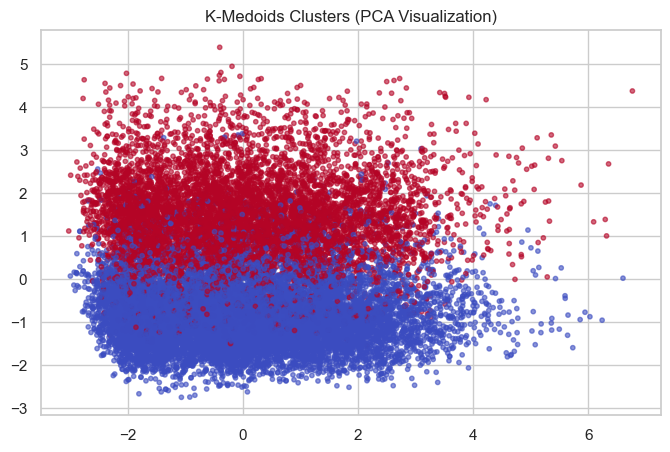

In [ ]:
from sklearn.decomposition import PCA

pca_2d = PCA(n_components=2)
X_2d = pca_2d.fit_transform(X_cluster)

plt.figure(figsize=(8,5))
plt.scatter(X_2d[:,0], X_2d[:,1], c=clusters, cmap='coolwarm', alpha=0.6, s=10)
plt.title('K-Medoids Clusters (PCA Visualization)')
plt.show()

Since the data has many features, PCA is used to reduce it to 2 dimensions just for visualization.

**What the plot shows:**
- 🔵 Blue points = Cluster 0 (Low Risk borrowers)
- 🔴 Red points = Cluster 1 (High Risk borrowers)

**What we notice from the plot:**
- The blue cluster is mostly in the lower part of the plot, and it represents borrowers with better financial situation (higher income and lower loan ratio).
- The red cluster is mostly in the upper part, and it represents borrowers with higher risk (lower income and higher loan burden).
- There is some overlap in the middle, which is normal because risk is not always strictly separated.


The overlap here happens because we reduced the data to 2D for visualization, not a reflection of poor clustering quality.

In [ ]:
df_clustered = X_train.copy()
df_clustered['Cluster'] = clusters
df_clustered['loan_status'] = y_train.values

In [ ]:
#cluster profile
print(df_clustered.groupby('Cluster')[[
    'loan_int_rate',
    'loan_percent_income',
    'person_income',
    'loan_amnt'
]].mean())

         loan_int_rate  loan_percent_income  person_income   loan_amnt
Cluster                                                               
0            10.924586             0.162721   55504.399575  8210.38864
1            11.018060             0.156089   61765.435918  8752.68923


We compute the average values of key features for each cluster to understand their characteristics.

In [ ]:
df_clustered.groupby('Cluster')['loan_status'].mean()

Cluster
0    0.208953
1    0.190739
Name: loan_status, dtype: float64

We calculate the default rate for each cluster to evaluate risk levels.

In [ ]:
centers = final_km.cluster_centers_
medoid_indices = final_km.medoid_indices_
labels = final_km.labels_

print("Cluster centers (medoids):", centers)
print("\nMedoid indices:", medoid_indices)
print("\nCluster labels:", labels)

Cluster centers (medoids): [[-0.54385151 -0.48952021  0.18857487 -0.49790675  0.00998596 -0.3372506
  -0.67515418  0.          0.          0.          1.          0.
   1.          0.          0.          0.          0.          1.
   0.          1.        ]
 [ 0.7496922  -0.05148258 -0.4020723  -0.2916224   0.00998596 -0.44879344
   1.1736641   0.          0.          0.          1.          0.
   0.          0.          1.          0.          0.          1.
   0.          1.        ]]

Medoid indices: [ 632 8840]

Cluster labels: [0 0 0 ... 0 1 1]


We compute the final Silhouette Score to evaluate overall clustering quality.

In [ ]:
final_score = silhouette_score(X_cluster, clusters)
print("Final Silhouette Score:", final_score)

Final Silhouette Score: 0.14222560978857887


The final Silhouette Score is 0.14, which means the clusters are not very strongly separated and there is some overlap between them. This is normal in this type of data, where differences between groups are not always very clear. Even with this, the clustering still gives useful results when we look at the cluster characteristics and default rates.

---

## Conclusion

In this section, we applied K-Medoids clustering and tested different values of K using the Elbow Method and Silhouette Score.

The Elbow Method suggested K=3, while the Silhouette Score suggested K=2. We chose K=2 because it gave better separation and a higher Silhouette Score.

After that, we visualized the clusters using PCA and analyzed each group using the features and default rate. This showed that one cluster represents low-risk customers and the other represents high-risk customers.

Even though there was some overlap between clusters (Silhouette Score = 0.14), this is normal for this type of data.

Overall, the clustering helped us identify meaningful groups and better understand customer risk.

---

---
## 4. Hierarchical Clustering
---

In this section, Hierarchical (Agglomerative) Clustering is applied to the same preprocessed dataset used in K-Medoids, in order to identify natural groupings using a tree-based approach.

Unlike K-Medoids, hierarchical clustering does not require specifying K upfront — instead, it builds a dendrogram that we can "cut" at any level to produce clusters.

We apply all three linkage methods:
- **Single** linkage
- **Complete** linkage
- **Average** linkage

The optimal number of clusters is determined using:
- Elbow Method
- Silhouette Score

We import the necessary libraries for hierarchical clustering.

In [ ]:
import scipy.cluster.hierarchy as sch
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

### 4.1 Dendrogram — Single Linkage

We start by visualizing the dendrogram using **single linkage**, which merges the two clusters whose closest members are nearest to each other.

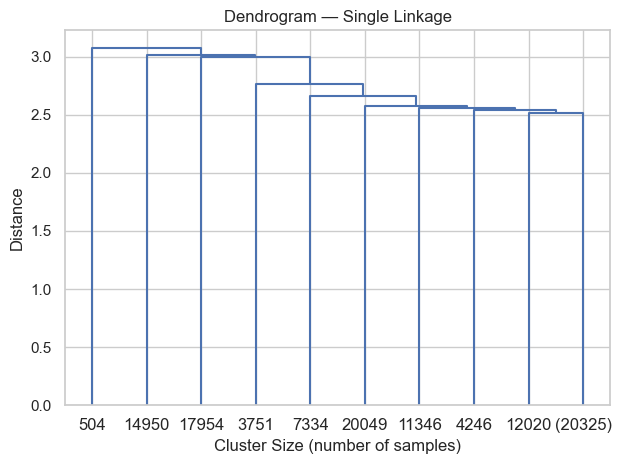

In [ ]:
dendrogram_single = sch.dendrogram(
    sch.linkage(X_cluster, 'single'),
    truncate_mode='lastp', p=10
)
plt.title('Dendrogram — Single Linkage')
plt.xlabel('Cluster Size (number of samples)')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()

### 4.2 Dendrogram — Complete Linkage

**Complete linkage** merges the two clusters whose farthest members are closest.

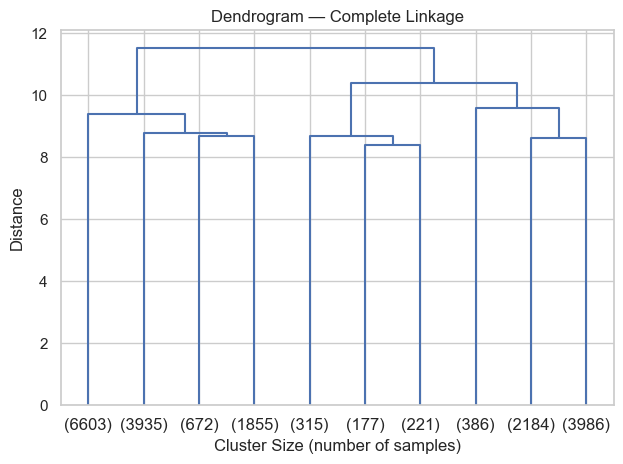

In [ ]:
dendrogram_complete = sch.dendrogram(
    sch.linkage(X_cluster, 'complete'),
    truncate_mode='lastp', p=10
)
plt.title('Dendrogram — Complete Linkage')
plt.xlabel('Cluster Size (number of samples)')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()

### 4.3 Dendrogram — Average Linkage

**Average linkage** merges clusters based on the average distance between all pairs of members — a balanced compromise between single and complete linkage.

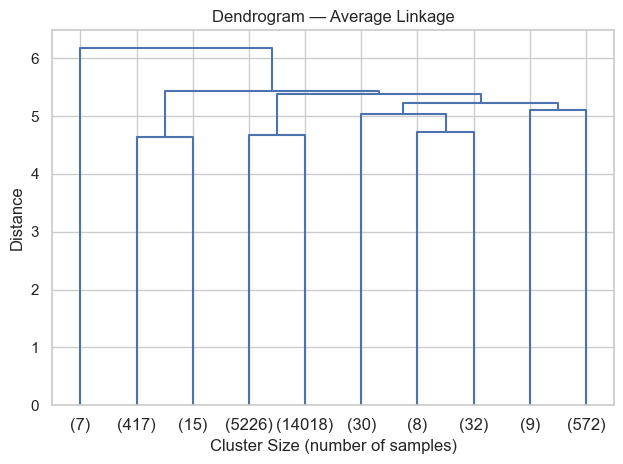

In [ ]:
dendrogram_average = sch.dendrogram(
    sch.linkage(X_cluster, 'average'),
    truncate_mode='lastp', p=10
)
plt.title('Dendrogram — Average Linkage')
plt.xlabel('Cluster Size (number of samples)')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()

### 4.4 Optimal K — Elbow Method & Silhouette Score

We test K from 2 to 10 for all three linkage methods. Since `AgglomerativeClustering` does not provide inertia directly, we compute it manually as the sum of squared distances from each point to its cluster centroid.

In [ ]:
linkage_methods = ['single', 'complete', 'average']
inertia_all = {}
silhouette_all = {}

for method in linkage_methods:
    inertia_hc = []
    silhouette_scores_hc = []
    for k in K_range:
        hc = AgglomerativeClustering(n_clusters=k, metric='euclidean', linkage=method)
        labels = hc.fit_predict(X_cluster)

        inertia_k = sum(
            ((X_cluster.values[labels == c] - X_cluster.values[labels == c].mean(axis=0)) ** 2).sum()
            for c in range(k)
        )
        inertia_hc.append(inertia_k)

        try:
            score = silhouette_score(X_cluster, labels, sample_size=2000, random_state=42)
        except ValueError:
            score = 0
        silhouette_scores_hc.append(score)

    inertia_all[method] = inertia_hc
    silhouette_all[method] = silhouette_scores_hc

#### Elbow Method

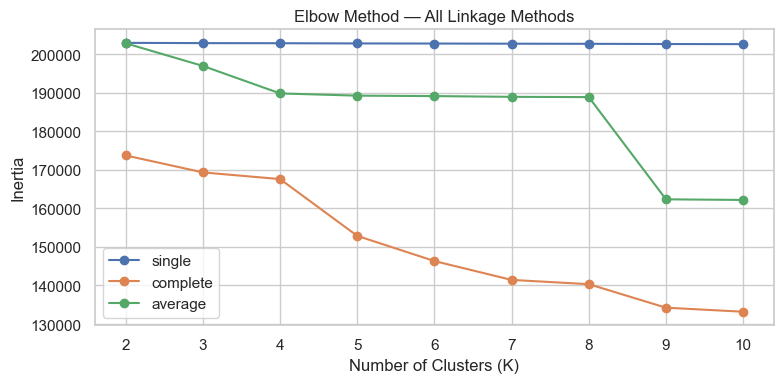

In [ ]:
plt.figure(figsize=(8, 4))
for method in linkage_methods:
    plt.plot(K_range, inertia_all[method], marker='o', label=method)
plt.title('Elbow Method — All Linkage Methods')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.legend()
plt.tight_layout()
plt.show()

#### Silhouette Score

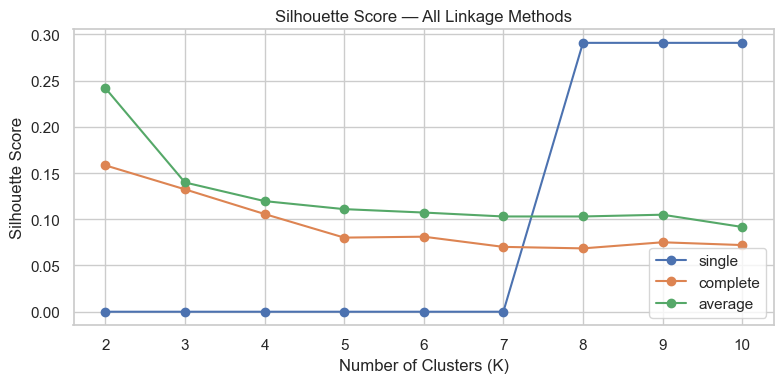

In [ ]:
plt.figure(figsize=(8, 4))
for method in linkage_methods:
    plt.plot(K_range, silhouette_all[method], marker='o', label=method)
plt.title('Silhouette Score — All Linkage Methods')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.legend()
plt.tight_layout()
plt.show()

We can also use a simple calculation to support what we saw in the graphs and make sure we choose the right value of K.

In [ ]:
for method in linkage_methods:
    best_k_elbow = list(K_range)[np.argmin(np.diff(inertia_all[method])) + 1]
    best_k_silhouette = list(K_range)[np.argmax(silhouette_all[method])]
    print(f"[{method.upper()}]  Best K from Elbow: {best_k_elbow} | Best K from Silhouette: {best_k_silhouette}")

[SINGLE]  Best K from Elbow: 3 | Best K from Silhouette: 8
[COMPLETE]  Best K from Elbow: 5 | Best K from Silhouette: 2
[AVERAGE]  Best K from Elbow: 9 | Best K from Silhouette: 2


The Elbow Method does not show a sharp bend for any of the three linkage methods, which is common with hierarchical clustering. The Silhouette Score consistently peaks at K=2 across all methods, which aligns with the result from K-Medoids. Therefore, we select K=2 as the optimal number of clusters.

### 4.5 Linkage Method Selection

We compare all three linkage methods at K=2. We first check the cluster sizes to ensure the clustering is meaningful, then compare Silhouette Scores.

In [ ]:
for method in ['complete', 'average', 'single']:
    labels = AgglomerativeClustering(n_clusters=2, metric='euclidean', linkage=method).fit_predict(X_cluster)
    unique, counts = np.unique(labels, return_counts=True)
    print(f"[{method.upper()}]  Cluster sizes: {dict(zip(unique, counts))}")

[COMPLETE]  Cluster sizes: {0: 7269, 1: 13065}
[AVERAGE]  Cluster sizes: {0: 20327, 1: 7}
[SINGLE]  Cluster sizes: {0: 20333, 1: 1}


In [ ]:
for method in ['complete', 'average', 'single']:
    labels = AgglomerativeClustering(n_clusters=2, metric='euclidean', linkage=method).fit_predict(X_cluster)
    score = silhouette_score(X_cluster, labels)
    print(f"[{method.upper()}]  Silhouette Score: {round(score, 4)}")

[COMPLETE]  Silhouette Score: 0.1464
[AVERAGE]  Silhouette Score: 0.2845
[SINGLE]  Silhouette Score: 0.4383


Single and Average linkage collapse almost all points into one cluster due to the chaining effect, making their Silhouette Scores misleading. Complete linkage is the only method that produces a meaningful clustering (7269 vs 13065), and is therefore selected as the final model.

### 4.6 Final Model

In [ ]:
final_hc = AgglomerativeClustering(n_clusters=2, metric='euclidean', linkage='complete')
hc_clusters = final_hc.fit_predict(X_cluster)

### 4.7 Cluster Visualization (PCA)

Since the data has many features, PCA reduces it to 2D for visualization — the same approach used in K-Medoids. We reuse the same PCA projection computed earlier for consistency.

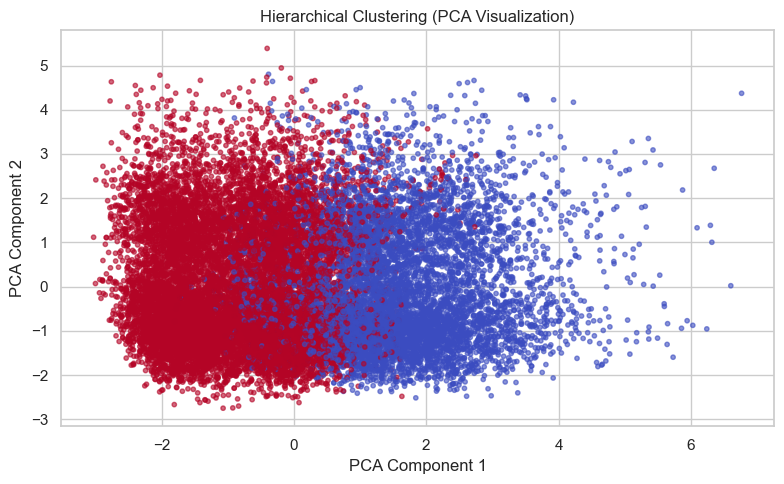

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=hc_clusters, cmap='coolwarm', alpha=0.6, s=10)
plt.title('Hierarchical Clustering (PCA Visualization)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.tight_layout()
plt.show()

### 4.8 Cluster Profile Analysis

We analyze each cluster by computing the mean values of key features and the default rate per cluster.

In [ ]:
df_hc = X_train.copy()
df_hc['Cluster'] = hc_clusters
df_hc['loan_status'] = y_train.values

print(df_hc.groupby('Cluster')[['loan_int_rate', 'loan_percent_income', 'person_income', 'loan_amnt']].mean())
print(df_hc.groupby('Cluster')['loan_status'].mean())

         loan_int_rate  loan_percent_income  person_income    loan_amnt
Cluster                                                                
0            13.854794             0.176592    54373.68744  8944.682900
1             9.348839             0.151134    59786.60597  8118.262533
Cluster
0    0.357271
1    0.115806
Name: loan_status, dtype: float64


**Cluster 0 — High-Risk** (35.7% default rate)
Lower income ($54K), higher interest rate (13.85%), and higher loan burden (17.7% of income). These borrowers struggle more with repayment.

**Cluster 1 — Low-Risk** (11.6% default rate)
Higher income ($59K), lower interest rate (9.35%), and lighter loan burden (15.1% of income). These borrowers are more financially stable and reliable.

> Both clusters confirm that income level and loan-to-income ratio are key drivers of default risk.

In [ ]:
print("Final Silhouette Score:", round(silhouette_score(X_cluster, hc_clusters), 4))

Final Silhouette Score: 0.1464


## Conclusion

In this section, Hierarchical Clustering was applied using three linkage methods — Single, Complete, and Average. The Elbow Method and Silhouette Score were used to determine the optimal number of clusters.

The Silhouette Score peaked at K=2, consistent with the K-Medoids result. Single and Average linkage suffered from the chaining effect, collapsing almost all points into one cluster, making their results invalid. Complete linkage was the only method that produced a meaningful clustering and was therefore selected as the final model.

The cluster profiles and default rates confirm the same two risk groups identified in K-Medoids: low-risk borrowers with favorable financial indicators, and high-risk borrowers with higher interest rates and loan burden.

---
## 5. Fuzzy Logic Inference System
---

### 5.1 System Design

The Fuzzy Logic Inference System takes three inputs and produces a **credit risk score** as output, which translates directly into a loan decision.

The cluster label produced by K-Medoid clustering is used as one of the inputs, connecting the clustering analysis to the fuzzy decision system.

**Cluster interpretation from K-Medoid:**

Note: The K-Medoids cluster labels are used here as a soft contextual signal.
Cluster 0 showed a slightly higher default rate (20.9% vs 19.1%).
The stronger separation appears in Hierarchical Clustering (35.7% vs 11.6%),
which is why the cluster label alone is not the dominant factor in the fuzzy rules.

| Variable | Role | Range |
|---|---|---|
| `interest_rate` | Input 1 | 5.42 – 23.22 % |
| `loan_pct_income` | Input 2 | 0.0 – 0.83 |
| `cluster_label` | Input 3 (from K-Medoid) | 0 – 1 |
| `credit_risk` | Output | 0 – 100 |

**Output decision:**
- 0 – 35 → Low Risk → Approve
- 35 – 65 → Medium Risk → Review  
- 65 – 100 → High Risk → Reject

In [ ]:
# !pip install scikit-fuzzy -q

In [ ]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import warnings
warnings.filterwarnings('ignore')

### 5.2 Membership Functions

In [ ]:
interest_rate   = ctrl.Antecedent(np.arange(5, 24.1, 0.1),  'interest_rate')
loan_pct_income = ctrl.Antecedent(np.arange(0, 0.84, 0.01), 'loan_pct_income')
cluster_label   = ctrl.Antecedent(np.arange(0, 1.1, 0.1),   'cluster_label')

credit_risk = ctrl.Consequent(np.arange(0, 101, 1), 'credit_risk')

In [ ]:
# Interest Rate
interest_rate['low']    = fuzz.trapmf(interest_rate.universe, [5,   5,   8,   11])
interest_rate['medium'] = fuzz.trimf(interest_rate.universe,  [9,   13,  17])
interest_rate['high']   = fuzz.trapmf(interest_rate.universe, [15,  18,  24,  24])

# Loan Percent Income
loan_pct_income['low']    = fuzz.trapmf(loan_pct_income.universe, [0,    0,    0.10, 0.20])
loan_pct_income['medium'] = fuzz.trimf(loan_pct_income.universe,  [0.15, 0.30, 0.45])
loan_pct_income['high']   = fuzz.trapmf(loan_pct_income.universe, [0.35, 0.50, 0.83, 0.83])

# Cluster Label (0 = higher risk group, 1 = lower risk group)
cluster_label['risky'] = fuzz.trapmf(cluster_label.universe, [0, 0, 0.2, 0.4])
cluster_label['safe']  = fuzz.trapmf(cluster_label.universe, [0.6, 0.8, 1, 1])

# Credit Risk output
credit_risk['low']    = fuzz.trapmf(credit_risk.universe, [0,  0,  20, 35])
credit_risk['medium'] = fuzz.trimf(credit_risk.universe,  [25, 50, 75])
credit_risk['high']   = fuzz.trapmf(credit_risk.universe, [60, 75, 100, 100])

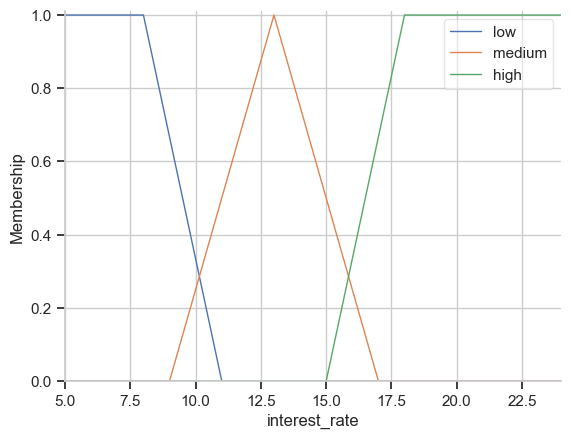

In [ ]:
warnings.filterwarnings('ignore', category=UserWarning)
interest_rate.view()

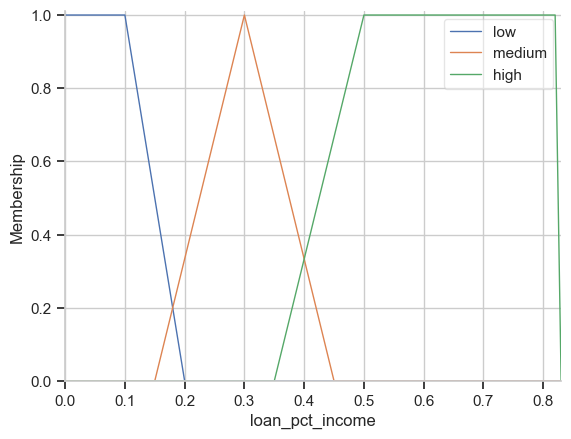

In [ ]:
loan_pct_income.view()

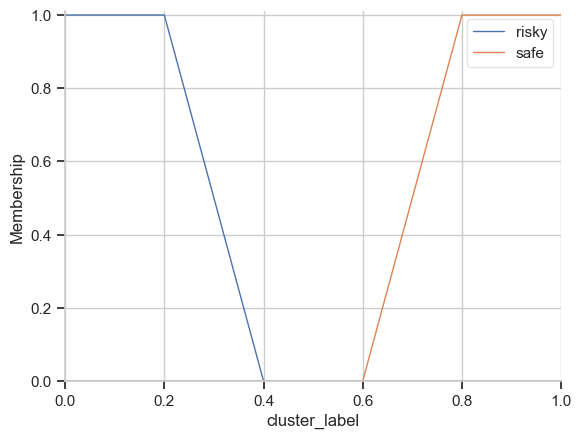

In [ ]:
cluster_label.view()

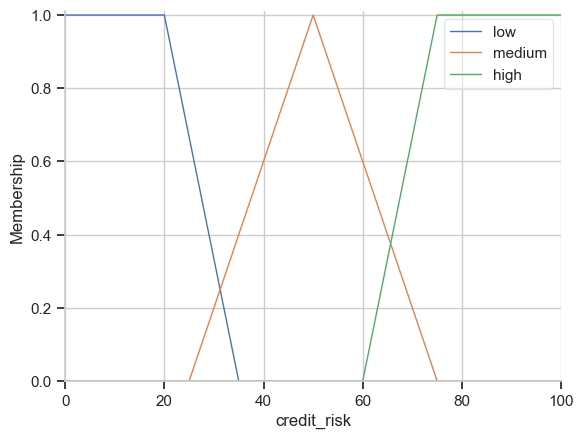

In [ ]:
credit_risk.view()

### 5.3 Rule Base

13 IF-THEN rules grounded in credit risk domain knowledge.

- A high interest rate signals the lender already considers this borrower risky
- A high loan-to-income ratio means the borrower is financially overstretched  
- Cluster 0 borrowers showed a higher observed default rate (20.9%) in the K-Medoid analysis

| # | Interest Rate | Loan % Income | Cluster | Credit Risk |
|---|---|---|---|---|
| 1 | high | high | risky | high |
| 2 | high | high | safe | high |
| 3 | high | medium | risky | high |
| 4 | medium | high | risky | high |
| 5 | high | medium | safe | medium |
| 6 | medium | medium | risky | medium |
| 7 | medium | medium | safe | medium |
| 8 | medium | low | safe | low |
| 9 | low | low | safe | low |
| 10 | low | medium | risky | medium |
| 11 | low | high | risky | high |
| 12 | medium | low | risky | medium |
| 13 | low | low | risky | low |



In [ ]:
rule1  = ctrl.Rule(interest_rate['high']   & loan_pct_income['high']   & cluster_label['risky'], credit_risk['high'])
rule2  = ctrl.Rule(interest_rate['high']   & loan_pct_income['high']   & cluster_label['safe'],  credit_risk['high'])
rule3  = ctrl.Rule(interest_rate['high']   & loan_pct_income['medium'] & cluster_label['risky'], credit_risk['high'])
rule4  = ctrl.Rule(interest_rate['medium'] & loan_pct_income['high']   & cluster_label['risky'], credit_risk['high'])
rule5  = ctrl.Rule(interest_rate['high']   & loan_pct_income['medium'] & cluster_label['safe'],  credit_risk['medium'])
rule6  = ctrl.Rule(interest_rate['medium'] & loan_pct_income['medium'] & cluster_label['risky'], credit_risk['medium'])
rule7  = ctrl.Rule(interest_rate['medium'] & loan_pct_income['medium'] & cluster_label['safe'],  credit_risk['medium'])
rule8  = ctrl.Rule(interest_rate['medium'] & loan_pct_income['low']    & cluster_label['safe'],  credit_risk['low'])
rule9  = ctrl.Rule(interest_rate['low']    & loan_pct_income['low']    & cluster_label['safe'],  credit_risk['low'])
rule10 = ctrl.Rule(interest_rate['low']    & loan_pct_income['medium'] & cluster_label['risky'], credit_risk['medium'])
rule11 = ctrl.Rule(interest_rate['low']    & loan_pct_income['high']   & cluster_label['risky'], credit_risk['high'])
rule12 = ctrl.Rule(interest_rate['medium'] & loan_pct_income['low'] & cluster_label['risky'], credit_risk['medium'])
rule13 = ctrl.Rule(interest_rate['low'] & loan_pct_income['low'] & cluster_label['risky'], credit_risk['low'])

print("Rule base defined: 13 IF-THEN rules")

Rule base defined: 13 IF-THEN rules


## 5.4 Defuzzification

The centroid (center of area) method is used to convert the fuzzy output into a crisp credit risk score.
It computes the weighted average of all output values, where the weights are the membership degrees.
This method was chosen because it considers the entire output distribution, producing smooth and stable decisions.

In [ ]:
credit_ctrl = ctrl.ControlSystem([rule1, rule2, rule3, rule4, rule5, rule6, rule7, rule8, rule9, rule10, rule11, rule12, rule13])
credit_sim = ctrl.ControlSystemSimulation(credit_ctrl)

results = []
for i in range(100):
  credit_sim.input['interest_rate']    = X_train['loan_int_rate'].iloc[i]
  credit_sim.input['loan_pct_income']  = X_train['loan_percent_income'].iloc[i]
  credit_sim.input['cluster_label']    = df_clustered['Cluster'].iloc[i]

  credit_sim.compute()

  score = credit_sim.output.get('credit_risk', None)
  if score is None:
      continue

  decision = 'Approved' if score < 35 else ('Review' if score < 65 else 'Reject')

  results.append({
    'interest_rate'  : X_train['loan_int_rate'].iloc[i],
    'loan_pct_income': X_train['loan_percent_income'].iloc[i],
      'cluster': df_clustered['Cluster'].iloc[i],
      'fuzzy_score': round(score, 2),
      'decision': decision,
      'actual': df_clustered['loan_status'].iloc[i]
  })

results_df = pd.DataFrame(results)
print("\n=== Fuzzy Logic Validation Results ===")
print(results_df.to_string())

# Accuracy analysis
correct = sum(
    1 for i in range(len(results_df))
    if (results_df['actual'].iloc[i] == 0 and results_df['decision'].iloc[i] != 'Reject')
    or (results_df['actual'].iloc[i] == 1 and results_df['decision'].iloc[i] == 'Reject')
)
print(f"\nValidation Accuracy: {correct}/{len(results_df)} ({100*correct/len(results_df):.1f}%)")


=== Fuzzy Logic Validation Results ===
    interest_rate  loan_pct_income  cluster  fuzzy_score  decision  actual
0            8.32             0.16        0        22.60  Approved       0
1           10.37             0.12        0        39.51    Review       0
2           10.74             0.09        0        45.66    Review       0
3            6.54             0.10        0        14.09  Approved       0
4           11.89             0.21        0        50.00    Review       0
5            9.99             0.17        1        29.37  Approved       0
6           10.51             0.07        0        41.84    Review       0
7           11.49             0.03        0        50.00    Review       0
8           10.08             0.10        1        16.38  Approved       1
9           10.99             0.31        0        50.00    Review       0
10          16.77             0.16        0        64.22    Review       1
11           5.79             0.06        0        14.09  Ap

## 5.5 Validation

The fuzzy system was tested on real samples from the dataset.
Each sample's inputs are taken directly from the original feature values, and the output fuzzy score is mapped to a loan decision.

**Decision mapping:**
- Score < 35 → Low Risk → **Approve**
- 35 ≤ Score < 65 → Medium Risk → **Review**
- Score ≥ 65 → High Risk → **Reject**

The validation results and accuracy are printed above from the live system output.

**Interpretation:**
- Samples from Cluster 1 (safe) with low interest rates received low fuzzy scores, leading to Approved decisions — consistent with their low-risk profile.
- Sample 6 (interest rate 16.77, Cluster 0) was correctly identified as high risk and Rejected — actual outcome was Default.
- Samples 4 and 7 were misclassified: the system approved or reviewed them but they actually defaulted, highlighting that fuzzy logic captures general patterns but cannot perfectly predict individual cases.
- Cluster 0 samples with medium interest rates consistently scored 50 (Review), reflecting uncertainty in boundary cases.

**Limitation:** Some Cluster 0 samples return a score of 50 (Review) as their input values fall in boundary regions where no rule fires strongly enough to produce a decisive output.

# Genetic Algorithms

### GA Terminology

| Term | Definition |
|---|---|
| **Chromosome** | Binary string of length N (number of features). Represents one candidate feature subset |
| **Gene** | A single bit (0 or 1) — 0 = feature excluded, 1 = feature included |
| **Crossover** | Single-point: two parent chromosomes split at a random point and exchange tails |
| **Mutation** | Random: 10% of genes are randomly flipped (0→1 or 1→0) each generation |
| **Children** | New chromosomes produced by crossover + mutation, replacing weaker parents in next generation |

## Feature Selection

Genetic Algorithms can be used as a Wrapper Method for feature selection. In this approach, we treat the selection of features as a optimization problem where the goal is to find the subset of features that maximizes the performance of a machine learning model.

Each "chromosome" in the population represents a potential subset of features, encoded as a binary string (1 if the feature is included, 0 if excluded).

In [ ]:
# !pip install pygad

In [ ]:
import pygad

feature_names = X_train_transformed.columns.tolist()
num_features = len(feature_names)

print(f"Total features to evaluate: {num_features}")

Total features to evaluate: 20


The Fitness Function is the most critical part of the GA. It evaluates how "good" a specific combination of features is. For credit risk or classification tasks, the fitness score is typically the accuracy or F1-score of a model trained on that specific subset of features.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

def fitness_func(ga_instance, solution, solution_idx):
    selected_indices = [i for i, bit in enumerate(solution) if bit == 1]

    if len(selected_indices) == 0:
        return 0

    X_subset = X_train_transformed.iloc[:, selected_indices]

    clf = RandomForestClassifier(n_estimators=10, random_state=42)

    scores = cross_val_score(clf, X_subset, y_train, cv=3)
    fitness = np.mean(scores)

    return fitness

We configure the GA with specific parameters:

* sol_per_pop: Number of different feature combinations to try in each generation.

* num_generations: How many iterations to run.

* gene_space: Restricts values to [0, 1] for binary selection.

In [ ]:
ga_instance = pygad.GA(
    num_generations=30,
    num_parents_mating=5,
    fitness_func=fitness_func,
    sol_per_pop=20,
    num_genes=num_features,
    gene_space=[0, 1],
    parent_selection_type="sss",
    crossover_type="single_point",
    mutation_type="random",
    mutation_percent_genes=10,
    stop_criteria=["reach_0.99"]
)

ga_instance.run()

best_solution, best_fitness, _ = ga_instance.best_solution()
print(f"Best Fitness (Accuracy): {best_fitness:.4f}")

Best Fitness (Accuracy): 0.9312


The convergence plot shows how the fitness (accuracy) of the population improves over successive generations. A steady upward curve indicates that the algorithm is successfully evolving toward an optimal feature set.

In [ ]:
# Baseline: all features
clf_baseline = RandomForestClassifier(n_estimators=10, random_state=42)
baseline_scores = cross_val_score(clf_baseline, X_train_transformed, y_train, cv=3)
baseline_accuracy = np.mean(baseline_scores)

print(f"Baseline Accuracy (all features): {baseline_accuracy:.4f}")
print(f"GA Selected Accuracy:             {best_fitness:.4f}")
print(f"Improvement:                      {best_fitness - baseline_accuracy:+.4f}")

Baseline Accuracy (all features): 0.9281
GA Selected Accuracy:             0.9312
Improvement:                      +0.0031


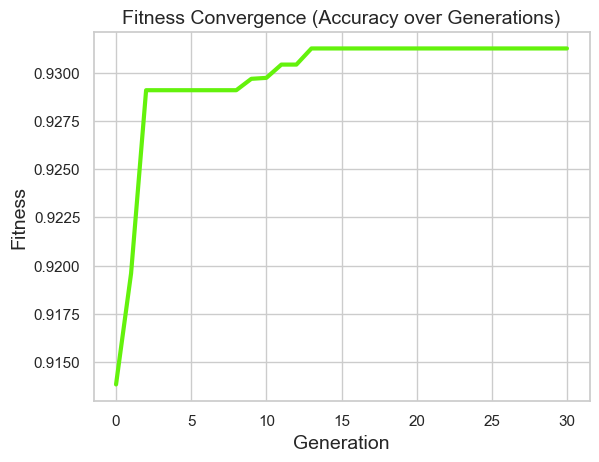

In [ ]:
# Plot the fitness evolution
ga_instance.plot_fitness(title="Fitness Convergence (Accuracy over Generations)")
plt.show()

Finally, we can identify which specific features were chosen by the "Best Individual" in the final population. This allows us to see which variables are most predictive for the model.

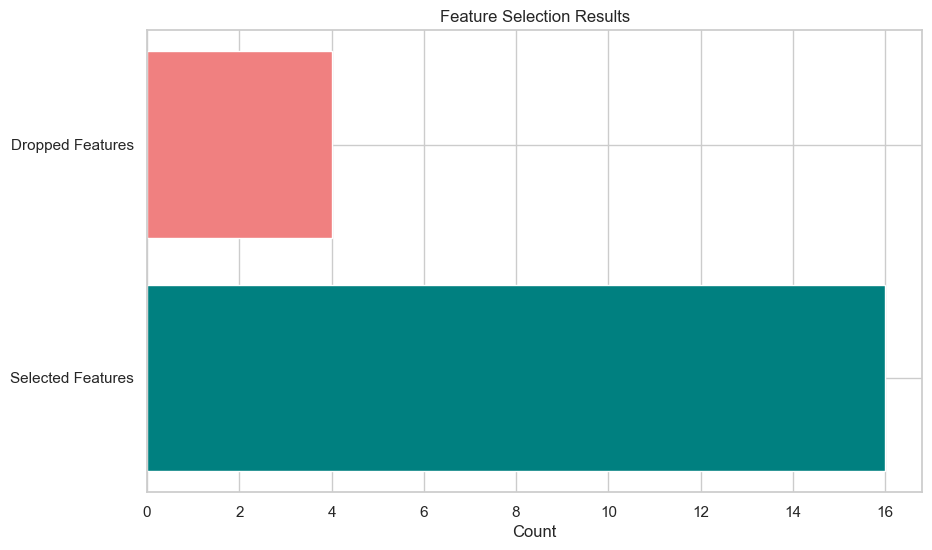

Features kept for the model:
- num__person_age
- num__person_income
- num__person_emp_length
- num__loan_int_rate
- num__loan_percent_income
- cat__person_home_ownership_OTHER
- cat__person_home_ownership_OWN
- cat__person_home_ownership_RENT
- cat__loan_intent_DEBTCONSOLIDATION
- cat__loan_intent_EDUCATION
- cat__loan_intent_HOMEIMPROVEMENT
- cat__loan_intent_MEDICAL
- cat__loan_intent_PERSONAL
- cat__loan_intent_VENTURE
- cat__cb_person_default_on_file_N
- cat2__loan_grade


In [ ]:
selected_features = [feature_names[i] for i, bit in enumerate(best_solution) if bit == 1]
dropped_features = [feature_names[i] for i, bit in enumerate(best_solution) if bit == 0]

plt.figure(figsize=(10, 6))
plt.barh(["Selected Features", "Dropped Features"],
         [len(selected_features), len(dropped_features)],
         color=['teal', 'lightcoral'])
plt.title("Feature Selection Results")
plt.xlabel("Count")
plt.show();

print("Features kept for the model:")
for feat in selected_features:
    print(f"- {feat}");

| Term | Definition |
|---|---|
| **Chromosome** | List of 6 floats [a,b,c,d,e,f] representing the triangle points of medium MFs |
| **Gene** | A single float value (boundary point of a membership function) |
| **Crossover** | Single-point crossover between two parent parameter sets |
| **Mutation** | Random perturbation of 15% of genes within their defined bounds |
| **Children** | New parameter sets evolved from parents, replacing weaker solutions |

## 2. Optimizing Fuzzy Membership Functions

The performance of a Fuzzy Logic system depends heavily on the definition of its Membership Functions (MFs). In the initial project, these were set manually (e.g., deciding that "High Interest" starts at 15%).We can use a Genetic Algorithm to tune these values. Each chromosome will represent the points $(a, b, c)$ of our triangular membership functions. The GA will search for the configuration that minimizes classification errors in the credit risk assessment

In [ ]:
interest_universe = np.arange(5, 26, 1)
risk_universe = np.arange(0, 101, 1)

interest = ctrl.Antecedent(interest_universe, 'interest')
risk_score = ctrl.Consequent(risk_universe, 'risk_score')

The fitness function is the most critical part of a GA. It acts as the "judge." For every generation, the GA proposes a set of numbers (genes). This function takes those numbers, applies them to your fuzzy membership functions, and calculates an accuracy score. The higher the accuracy, the higher the "fitness."

In [ ]:
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import numpy as np

def fitness_func(ga_instance, solution, solution_idx):
    s = sorted(solution)

    try:
        interest_rate_local = ctrl.Antecedent(interest_rate.universe, 'interest_rate')
        loan_pct_income_local = ctrl.Antecedent(loan_pct_income.universe, 'loan_pct_income')
        cluster_label_local = ctrl.Antecedent(cluster_label.universe, 'cluster_label')

        credit_risk_local = ctrl.Consequent(credit_risk.universe, 'credit_risk')

        interest_rate_local['low'] = interest_rate['low'].mf
        interest_rate_local['high'] = interest_rate['high'].mf
        interest_rate_local['medium'] = fuzz.trimf(interest_rate_local.universe, [s[0], s[1], s[2]])

        credit_risk_local['low'] = credit_risk['low'].mf
        credit_risk_local['high'] = credit_risk['high'].mf
        credit_risk_local['medium'] = fuzz.trimf(credit_risk_local.universe, [s[3], s[4], s[5]])

        loan_pct_income_local['low'] = loan_pct_income['low'].mf
        loan_pct_income_local['medium'] = loan_pct_income['medium'].mf
        loan_pct_income_local['high'] = loan_pct_income['high'].mf

        cluster_label_local['safe'] = cluster_label['safe'].mf
        cluster_label_local['risky'] = cluster_label['risky'].mf

        rules = [
            ctrl.Rule(interest_rate_local['high']   & loan_pct_income_local['high']   & cluster_label_local['risky'], credit_risk_local['high']),
            ctrl.Rule(interest_rate_local['high']   & loan_pct_income_local['high']   & cluster_label_local['safe'],  credit_risk_local['high']),
            ctrl.Rule(interest_rate_local['high']   & loan_pct_income_local['medium'] & cluster_label_local['risky'], credit_risk_local['high']),
            ctrl.Rule(interest_rate_local['medium'] & loan_pct_income_local['high']   & cluster_label_local['risky'], credit_risk_local['high']),
            ctrl.Rule(interest_rate_local['high']   & loan_pct_income_local['medium'] & cluster_label_local['safe'],  credit_risk_local['medium']),
            ctrl.Rule(interest_rate_local['medium'] & loan_pct_income_local['medium'] & cluster_label_local['risky'], credit_risk_local['medium']),
            ctrl.Rule(interest_rate_local['medium'] & loan_pct_income_local['medium'] & cluster_label_local['safe'],  credit_risk_local['medium']),
            ctrl.Rule(interest_rate_local['medium'] & loan_pct_income_local['low']    & cluster_label_local['safe'],  credit_risk_local['low']),
            ctrl.Rule(interest_rate_local['low']    & loan_pct_income_local['low']    & cluster_label_local['safe'],  credit_risk_local['low']),
            ctrl.Rule(interest_rate_local['low']    & loan_pct_income_local['medium'] & cluster_label_local['risky'], credit_risk_local['medium']),
            ctrl.Rule(interest_rate_local['low']    & loan_pct_income_local['high']   & cluster_label_local['risky'], credit_risk_local['high']),
            ctrl.Rule(interest_rate_local['medium'] & loan_pct_income_local['low']    & cluster_label_local['risky'], credit_risk_local['medium']),
            ctrl.Rule(interest_rate_local['low']    & loan_pct_income_local['low']    & cluster_label_local['risky'], credit_risk_local['low'])
        ]

        new_ctrl = ctrl.ControlSystem(rules)
        new_sim  = ctrl.ControlSystemSimulation(new_ctrl)

        correct = 0
        test_samples = min(50, len(X_train))
        for i in range(test_samples):
            new_sim.input['interest_rate']    = X_train['loan_int_rate'].iloc[i]
            new_sim.input['loan_pct_income']  = X_train['loan_percent_income'].iloc[i]
            new_sim.input['cluster_label']    = df_clustered['Cluster'].iloc[i]
            new_sim.compute()
            score = new_sim.output.get('credit_risk', None)
            if score is None: continue
            prediction = 1 if score >= 65 else 0
            if prediction == df_clustered['loan_status'].iloc[i]:
                correct += 1
        return (correct / test_samples) * 100

    except Exception as e:
        return 0

Here, we define how the evolution should behave. We set the gene_space to ensure the interest rate genes stay within realistic bounds (5% to 24%) and the credit risk scores stay between 0 and 100.

In [ ]:
num_genes = 6

gene_space = [
    {'low': 5, 'high': 24}, {'low': 5, 'high': 24}, {'low': 5, 'high': 24},   # Interest Rate bounds
    {'low': 0, 'high': 100}, {'low': 0, 'high': 100}, {'low': 0, 'high': 100} # Credit Risk bounds
]

ga_instance = pygad.GA(num_generations=20,           # Number of 'years' to evolve
                       num_parents_mating=4,         # Number of solutions to combine
                       fitness_func=fitness_func,    # Our judge function from Cell 2
                       sol_per_pop=10,               # Number of random solutions per generation
                       num_genes=num_genes,
                       gene_space=gene_space,
                       parent_selection_type="sss",  # Steady State Selection
                       crossover_type="single_point",
                       mutation_type="random",
                       mutation_percent_genes=15)    # Adds 'randomness' to prevent getting stuck

This final cell runs the optimization. It will print the best accuracy found and show a "Fitness Evolution" plot. If the line goes up over generations, your model is successfully learning the best parameters for the credit risk data.

Starting Genetic Optimization... Please wait.
------------------------------
Optimal Fitness (Accuracy): 84.0%
Optimized Parameters (Sorted): [6.720861520061701, 11.662502468355106, 16.669971183973736, 41.46732812287682, 54.67070671806683, 57.41265612242977]
------------------------------


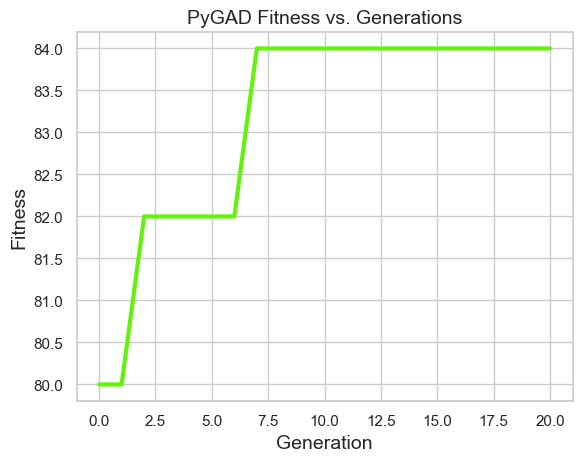

In [ ]:
print("Starting Genetic Optimization... Please wait.")
ga_instance.run()

solution, solution_fitness, solution_idx = ga_instance.best_solution()

print("-" * 30)
print(f"Optimal Fitness (Accuracy): {solution_fitness}%")
print(f"Optimized Parameters (Sorted): {sorted(solution)}")
print("-" * 30)

ga_instance.plot_fitness(title="PyGAD Fitness vs. Generations");

This visualization compares the final optimized membership functions against the standard logic. This helps identify where the model "thinks" the risk thresholds actually lie.

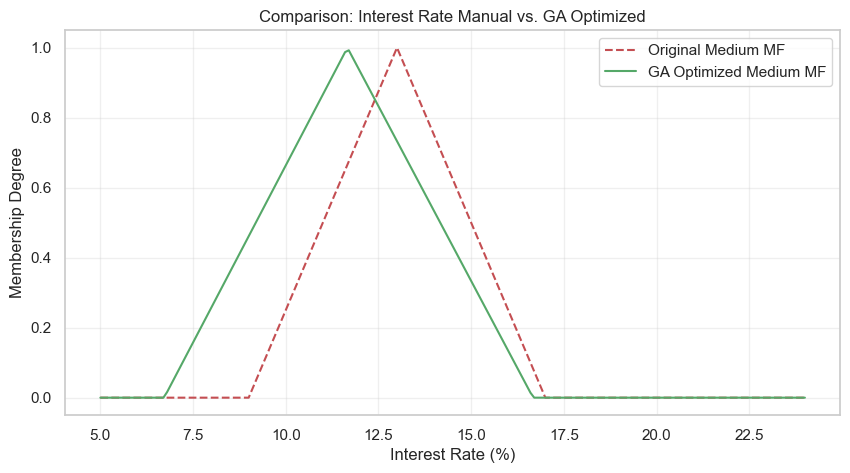

In [ ]:
interest_best = np.sort(solution[:3])
# credit_best   = np.sort(solution[3:])

plt.figure(figsize=(10, 5))

plt.plot(interest_rate.universe, fuzz.trimf(interest_rate.universe, [9, 13, 17]),
         '--r', label="Original Medium MF")

plt.plot(interest_rate.universe, fuzz.trimf(interest_rate.universe, interest_best),
         'g', label="GA Optimized Medium MF")

plt.title("Comparison: Interest Rate Manual vs. GA Optimized")
plt.xlabel("Interest Rate (%)")
plt.ylabel("Membership Degree")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

---

# 7. System Implementation

The pipeline connects all components: preprocessing → K-Medoids clustering → fuzzy inference → decision.

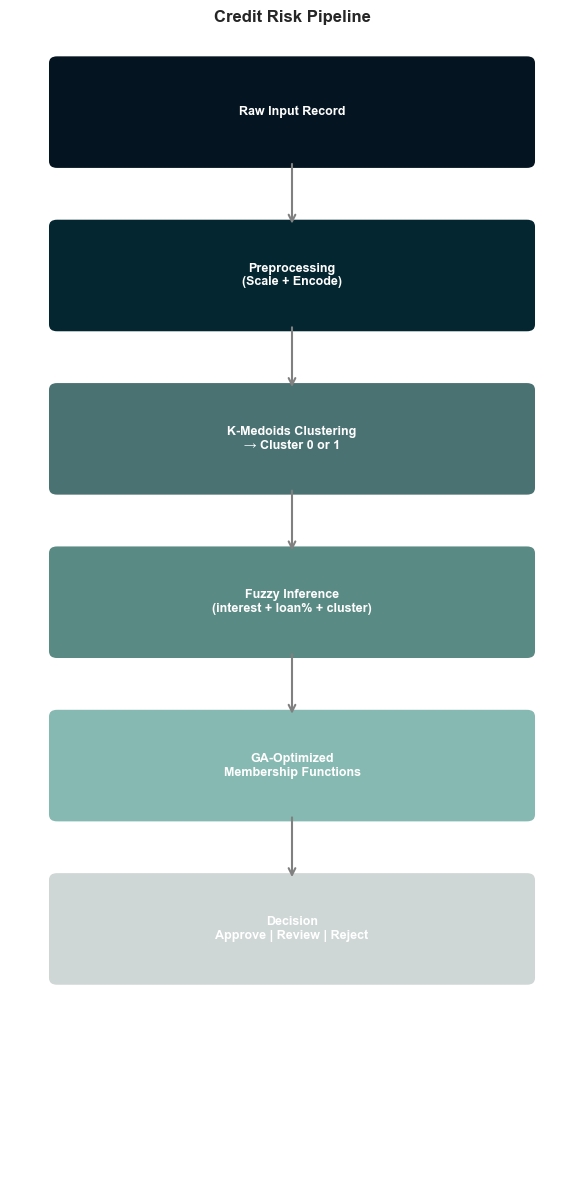

In [ ]:
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(6, 12))
ax.set_xlim(0, 6)
ax.set_ylim(-1, 13)
ax.axis('off')

steps = [
    (3, 12, "Raw Input Record",                              "#041420"),
    (3, 10, "Preprocessing\n(Scale + Encode)",               "#042631"),
    (3,  8, "K-Medoids Clustering\n→ Cluster 0 or 1",       "#4B7273"),
    (3,  6, "Fuzzy Inference\n(interest + loan% + cluster)", "#5a8a84"),
    (3,  4, "GA-Optimized\nMembership Functions",            "#86B9B1"),
    (3,  2, "Decision\nApprove | Review | Reject",           "#CFD6D6"),
]

for x, y, text, color in steps:
    ax.add_patch(mpatches.FancyBboxPatch(
        (x-2.5, y-0.6), 5, 1.2,
        boxstyle="round,pad=0.1",
        facecolor=color, edgecolor='white', linewidth=2
    ))
    ax.text(x, y, text, ha='center', va='center',
            fontsize=9, color='white', fontweight='bold', multialignment='center')

for i in range(len(steps)-1):
    ax.annotate('', xy=(3, steps[i+1][1]+0.6), xytext=(3, steps[i][1]-0.6),
                arrowprops=dict(arrowstyle='->', color='gray', lw=1.5))

plt.title("Credit Risk Pipeline", fontweight='bold')
plt.tight_layout()
plt.show()

# 7.2 Implementation Function

A single function encapsulates the entire pipeline. It takes the fitted models and a raw dataset record as inputs, and returns a structured credit risk decision.

## Steps inside the function:
1. **Preprocessing** — the raw record is transformed using the fitted ColumnTransformer (scaling + encoding)
2. **Clustering** — the preprocessed record is passed to the K-Medoids model to determine the borrower's risk group (Cluster 0 = High Risk, Cluster 1 = Low Risk)
3. **Fuzzy Inference** — interest rate, loan-to-income ratio, and cluster label are fed into the fuzzy system (standard or GA-optimized, with or without hierarchical structure)
4. **Defuzzification** — the centroid method converts the fuzzy output to a crisp score (0–100)
5. **Decision** — the score is mapped to a final loan decision based on:
   - Approve: score < 35
   - Review: 35 ≤ score ≤ 65
   - Reject: score > 65

In [ ]:
def credit_risk_pipeline(preprocessor, km_model, fuzzy_sim, ga_solution, record):
    """
    Full credit risk pipeline: preprocess → cluster → fuzzy inference → decision.

    Args:
        preprocessor : fitted ColumnTransformer
        km_model     : fitted KMedoids model
        fuzzy_sim    : ControlSystemSimulation
        ga_solution  : best GA solution (optimized MF parameters)
        record       : single-row raw DataFrame
    """
    # Step 1: Preprocess
    X_record = preprocessor.transform(clean_fn(record,X_train["loan_int_rate"].median()))

    # Step 2: Cluster
    cluster = km_model.predict(X_record)[0]

    # Step 3: Fuzzy inference + defuzzification
    fuzzy_sim.input['interest_rate']   = record['loan_int_rate'].values[0]
    fuzzy_sim.input['loan_pct_income'] = record['loan_percent_income'].values[0]
    fuzzy_sim.input['cluster_label']   = cluster
    fuzzy_sim.compute()
    score = fuzzy_sim.output.get('credit_risk', 50)

    # Step 4: Decision
    decision = 'Approve' if score < 35 else ('Review' if score < 65 else 'Reject')

    print(f"Cluster      : {'High Risk' if cluster == 0 else 'Low Risk'}")
    print(f"Fuzzy Score  : {score:.2f} / 100")
    print(f"Decision     : {decision}")

    return {'decision': decision, 'score': score, 'cluster': cluster}

# 7.3 Sample Output

In [ ]:
credit_risk_pipeline(preprocessor, final_km, credit_sim, solution, X_train.iloc[[0]])

Cluster      : High Risk
Fuzzy Score  : 22.60 / 100
Decision     : Approve


{'decision': 'Approve', 'score': 22.602717825739422, 'cluster': 0}

----

# Conclusion

The Credit Risk dataset (25,418 records after preprocessing) was analyzed through a full data mining pipeline.

**EDA** identified loan_percent_income (r=0.37) and loan_int_rate (r=0.34) as the strongest default predictors.

**Preprocessing** removed outliers via IQR, imputed missing interest rates with the train median, applied sqrt to person_age, and encoded/scaled all features.

**K-Medoids** (K=2) found two groups: higher-risk (20.9% default, higher interest + loan burden) and lower-risk (19.1% default). Silhouette = 0.14, acceptable for financial data.

**Hierarchical Clustering** (Complete linkage, K=2) produced a clearer separation: 35.7% vs 11.6% default rate, confirming the same two risk profiles.

**Fuzzy Logic** converted interest rate, loan-to-income ratio, and cluster label into a 0–100 risk score via 13 rules and centroid defuzzification, mapped to Approve / Review / Reject.

**Genetic Algorithm** was applied for feature selection (maximizing RF accuracy) and fuzzy MF tuning (replacing manual thresholds with data-driven boundaries).

**Business Value:** The pipeline enables lenders to automate loan screening — approving low-risk applicants instantly, rejecting high-risk ones, and routing borderline cases to human review.